# USAGE OF THE DIFFUSION MODEL

In [20]:
%run init_notebook.py

import torch.nn as nn
from torchvision.datasets import FashionMNIST, QMNIST, KMNIST
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import time
import json
from tqdm import tqdm  # import the class directly

import torchaudio
import torchaudio.transforms as T
from src.dataset import NSynth
import torch
from src.diffusion import *
from src.utils.models import adjust_shape, compute_magnitude_and_phase, compute_magnitude_and_phase_sin_cos
import src.utils.audio_utils as au
import math
from IPython.display import Audio, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

root = r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion"
paths = {
    'minst' : {
        'root': root + r"\minst",
        'model': root + r"\minst\model.pth",
        'object': root + r"\minst\object.pth",
        'config': root + r"\minst\config.json",
        'scheduler': root + r"\minst\scheduler.pth",
        'checkpoint': root + r"\minst\checkpoint.pth",
        'dataset' : r"C:\Users\Articuno\Desktop\TFG-info\data\mnist"
    },
    'audio' : {
        'root': root + r"\audio",
        'model': root + r"\audio\model.pth",
        'config': root + r"\audio\config.json",
        'object': root + r"\audio\object.pth",
        'scheduler': root + r"\audio\scheduler.pth",
        'checkpoint': root + r"\audio\checkpoint.pth"
    },
    'latent' : {
        'root': root + r"\latent",
        'model': root + r"\latent\model.pth",
        'object': root + r"\latent\object.pth",
        'config': root + r"\latent\config.json",
        'scheduler': root + r"\latent\scheduler.pth",
        'checkpoint': root + r"\latent\checkpoint.pth",
        'dataset_training' : r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\latent\dataset\training.pt",
        'training_norm_params' :  r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\latent\dataset\training_params.pt",
    },
    'encoder_latent' : {
        'root': root + r"\encoder_latent",
        'model': root + r"\encoder_latent\model.pth",
        'object': root + r"\encoder_latent\object.pth",
        'config': root + r"\encoder_latent\config.json",
        'scheduler': root + r"\encoder_latent\scheduler.pth",
        'checkpoint': root + r"\encoder_latent\checkpoint.pth",
        'dataset_training' : r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\encoder_latent\dataset\training.pt",
        'dataset_validation' : r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\encoder_latent\dataset\validation.pt",
        'training_norm_params' :  r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\encoder_latent\dataset\training_params.pt",
    }
}

def show_loss_plot(losses):
    epochs_list = [d['epoch'] for d in losses]
    loss_list   = [d['loss']  for d in losses]
    lr_list     = [d['lr']    for d in losses]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    ax1.plot(epochs_list, loss_list)
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.grid(True)

    ax2.plot(epochs_list, lr_list, color='orange')
    ax2.set_ylabel('Learning Rate')
    ax2.set_xlabel('Epoch')
    ax2.set_title('Learning Rate Schedule')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

## LOAD MODELS

In [21]:
from src.diffusion_setups.setup_audio import setup_audio_model
from src.diffusion_setups.setup_minst import setup_minst_model
from src.diffusion_setups.setup_latent import setup_latent_model

def load_audio_model():
    config = {}
    with open(paths['audio']['config'], 'r') as f:
        config = json.load(f) 
    model, scheduler, _ = setup_audio_model(
        timesteps=config['timesteps'],
        channels=config['channels'],
        norm_groups=config['norm_groups'],
        emb_dim=config['emb_dim'],
        n_fft=config['n_fft'],
        hop_length=config['hop_length'],
        win_length=config['win_length']
    )
    model = torch.load(paths['audio']['model'])
    scheduler = torch.load(paths['audio']['scheduler'])
    return model, scheduler

def load_minst_model():
    config = {}
    with open(paths['minst']['config'], 'r') as f:
        config = json.load(f)  
    model, scheduler, _ = setup_minst_model(
        timesteps=config['timesteps'],
        channels=config['channels'],
        norm_groups=config['norm_groups'],
        emb_dim=config['emb_dim']
    )
    # model.load_state_dict(torch.load(paths['minst']['model']))
    model = torch.load(paths['minst']['model'])
    scheduler = torch.load(paths['minst']['scheduler'])
    return model, scheduler

def load_latent_model(source='latent'):
    config = {}
    with open(paths[source]['config'], 'r') as f:
        config = json.load(f)    
    model, scheduler, _ = setup_latent_model(
        timesteps=config['timesteps'],
        emb_dim=config['emb_dim'],
        hidden_dims=config['hidden_dims'],
        latent_dim=config['latent_dim'],
        deep=config['deep'],
        increase_dims=config['increase_dims']
    )
    model = torch.load(paths[source]['model'])
    scheduler = torch.load(paths[source]['scheduler'])
    return model, scheduler

## SAMPLE IMAGES

In [58]:

def sample_raw_img(model, scheduler, image_size=(1, 28, 28), num_images=1):
    model.eval() # NS
    # with torch.no_grad():
    
    x = torch.randn(num_images, *image_size, device=device) # imagen de ruidio inicial
    T = scheduler.alpha_bar.shape[0]
    
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar
    with torch.no_grad():

        for t in reversed(range(T)):
            t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

            # predicción de ruido
            e_pred = model(x, t_batch)
            
            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]
            
            # beta_t = beta_t.view(1,1,1,1)
            # alpha_t = alpha_t.view(1,1,1,1)
            # alpha_bar_t = alpha_bar_t.view(1,1,1,1)


            # Coeficientes DDPM
            coef1 = 1 / torch.sqrt(alpha_t)
            coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

            mu = coef1 * (x - coef2 * e_pred)

            if t > 0:
                noise = torch.randn_like(x)
                # sigma_t = torch.sqrt(beta_t)
                sigma_t = torch.sqrt(beta_t * (1 - alpha_bars[t-1]) / (1 - alpha_bars[t]))

                x = mu + sigma_t * noise
            else:
                x = mu

        x = x.cpu()
        
    return x

def denoise_img(model, scheduler, noisy_img, step_imgs=10):
    model.eval()
    xs = [noisy_img]
    x = noisy_img.to(device)
    T = scheduler.alpha_bar.shape[0]
    
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar
    
    with torch.no_grad():
        for t in reversed(range(T)):
            
            t_batch = torch.full((x.size(0),), t, device=device, dtype=torch.long)

            e_pred = model(x, t_batch)
            
            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            coef1 = 1 / torch.sqrt(alpha_t)
            coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

            mu = coef1 * (x - coef2 * e_pred)

            # if t > 0:
            #     noise = torch.randn_like(x)
            #     sigma_t = torch.sqrt(beta_t)
            #     x = mu + sigma_t * noise
            # else:
            #     x = mu
                        
            if t > 0:
                noise = torch.randn_like(x)
                # sigma_t = torch.sqrt(beta_t * (1 - alpha_bars[t-1]) / (1 - alpha_bars[t]))
                sigma_t = torch.sqrt(beta_t)
                x = mu + sigma_t * noise
            else:
                x = mu
                
            if t % (T // step_imgs) == 0:
                xs.append(x.cpu())
            
        xs.append(x.cpu())
    return xs
    
def sample_latent(model, scheduler, latent_dim=200, num_samples=1, source='latent'):
    model.eval()
    x = torch.randn(num_samples, latent_dim, device=device)
    T = scheduler.alpha_bar.shape[0]
    
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar
    
    with torch.no_grad():
        for t in reversed(range(T)):
            t_batch = torch.full((num_samples,), t, device=device, dtype=torch.long)

            e_pred = model(x, t_batch)
            
            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            coef1 = 1 / torch.sqrt(alpha_t)
            coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

            mu = coef1 * (x - coef2 * e_pred)

            if t > 0:
                noise = torch.randn_like(x)
                sigma_t = torch.sqrt(beta_t)
                x = mu + sigma_t * noise
            else:
                x = mu

        x = x.cpu()
        
    params = torch.load(paths[source]['training_norm_params'])
    latent_mean = params['mean']
    latent_std = params['std']
    z = (x * latent_std) + latent_mean    
    
    return z

def sample_audio(decoder, latent_model, scheduler, n_fft=1500, win_length=1500, hop_length=250, num_samples=1):
    latent_samples = sample_latent(latent_model, scheduler, num_samples=num_samples)
    ws = []
    with torch.no_grad():
        for l in latent_samples:
            x = decoder.decoder(l.unsqueeze(0).to(device))  # (1, 2, H, W)
            wave = get_sound(x, n_fft=n_fft, win_length=win_length, hop_length=hop_length)
            ws.append(wave)
    return ws

def sample_audio_n_spect(decoder, latent_model, scheduler, n_fft=1500, win_length=1500, hop_length=250):
    z = sample_latent(latent_model, scheduler, num_samples=1)
    x = decoder.decoder(z.to(device))  # (1, 2, H, W)
    wave = get_sound(x, n_fft=n_fft, win_length=win_length, hop_length=hop_length)
    return wave, x


In [ ]:
def get_sound(x, n_fft=1500, win_length=1500, hop_length=250, griffin_lim=0):
    
    if griffin_lim > 0:
        return _get_sound_gl(x, n_fft=n_fft, win_length=win_length, hop_length=hop_length, n_iter=griffin_lim)
    else:
        istft_transform = T.InverseSpectrogram(
            n_fft=n_fft, win_length=win_length, hop_length=hop_length, onesided=False
        ).to(device)
        
        mag   = x[:, 0, :, :]         # (B, H, W)
        phase = x[:, 1, :, :]         # (B, H, W)
        
        complex_stft = mag * torch.exp(1j * phase)  # (B, H, W)

        # Inverse STFT to waveform
        wave = istft_transform(complex_stft)  # (B, T)

        wave = wave.squeeze().cpu().numpy()
    return wave

def _get_sound_gl(x, n_fft=1500, win_length=1500, hop_length=250, n_iter=64):
    mag = x[:, 0, :, :]                      # (B, 1500, 251)
    mag_onesided = mag[:, :n_fft//2 + 1, :]  # (B, 751, 251) — toda la info real

    griffin_lim = torchaudio.transforms.GriffinLim(
        n_fft=n_fft,        # Usa el mismo n_fft que en tu STFT
        hop_length=hop_length,    # Usa el mismo hop_length
        n_iter=n_iter          # 32 iteraciones suele bastar para buena calidad
    ).to(device)

    # griffin_lim = T.GriffinLim(
    #     n_fft=n_fft,
    #     win_length=win_length,
    #     hop_length=hop_length,
    #     power=1.0,
    #     n_iter=n_iter,
    # ).to(x.device)

    wave = griffin_lim(mag_onesided)
    return wave.squeeze().cpu().numpy()

In [39]:
def show_imgs(xs, cols=5, color=False):
    rows = math.ceil(len(xs) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    for i in range(len(xs)):
        img = xs[i][0].detach().cpu()
        if not color:  # grayscale (1, H, W)
            axes[i].imshow(img.squeeze().numpy(), cmap='gray')
        else:                   # RGB (3, H, W)
            axes[i].imshow(img.permute(1, 2, 0).numpy())
        axes[i].axis('off')

    # Ocultar ejes sobrantes si n no es múltiplo de cols
    for j in range(len(xs), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    
def display_audio(waves, sample_rate=16000):
    for wave in waves:
        au.listen(wave, sample_rate)
        
def display_tensor(tensor):
    """
    Muestra un tensor de shape [1, 2, 1500, 251] en grande.
    Muestra solo el canal de magnitud (canal 0).
    El eje Y representa frecuencia en escala logarítmica.
    """
    # assert tensor.shape == torch.Size([1, 2, 1500, 251]), f"Shape inesperado: {tensor.shape}"

    batch = tensor[0]  # [2, 1500, 251]

    i = 0  # el otro canal es el de la fase
    canal = batch[i].detach().cpu().numpy()  # [1500, 251]

    fig, ax = plt.subplots(1, 1, figsize=(20, 10))

    img = ax.imshow(
        canal,
        aspect='auto',
        origin='lower',
        cmap='viridis',
        extent=[0, 251, 0, 1500]
    )

    # Escala logarítmica en Y
    ax.set_yscale('symlog')  # symlog permite empezar desde 0 (log puro no puede)

    # Ticks representativos de frecuencia log
    freq_ticks = [1, 10, 50, 100, 200, 500, 1000, 1500]
    ax.set_yticks(freq_ticks)
    ax.set_yticklabels([str(f) for f in freq_ticks], fontsize=11)

    ax.set_title('Canal 1 - Magnitud', fontsize=18)
    ax.set_xlabel('Tiempo (frames)', fontsize=13)
    ax.set_ylabel('Frecuencia (escala logarítmica)', fontsize=13)

    plt.colorbar(img, ax=ax, label='Magnitud')
    plt.suptitle('Espectrograma - Tensor [1, 2, 1500, 251]', fontsize=20)
    plt.tight_layout()
    plt.show()
    
def display_spectrogram(waveform, sample_rate=16000):
    """
    Muestra el espectrograma Mel de una onda (62500,) en grande.
    
    Args:
        waveform: numpy array o tensor de shape (62500,)
        sample_rate: frecuencia de muestreo en Hz (por defecto 22050)
    """
    import librosa
    import librosa.display

    # Convertir a numpy si es tensor
    if hasattr(waveform, 'detach'):
        waveform = waveform.detach().cpu().numpy()
    waveform = waveform.squeeze().astype(np.float32)

    n_samples = len(waveform)
    duracion = n_samples / sample_rate

    S = librosa.feature.melspectrogram(y=waveform, sr=sample_rate, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)

    fig, ax = plt.subplots(figsize=(20, 8))

    img = librosa.display.specshow(
        S_db,
        sr=sample_rate,
        x_axis='time',
        y_axis='mel',
        ax=ax,
        cmap='viridis'
    )
    ax.set_title(f'Espectrograma Mel — {duracion:.2f}s · {sample_rate}Hz', fontsize=18)
    ax.set_xlabel('Tiempo (segundos)', fontsize=13)
    ax.set_ylabel('Frecuencia Mel (Hz)', fontsize=13)
    plt.colorbar(img, ax=ax, format='%+2.0f dB', label='Decibelios')

    plt.tight_layout()
    plt.show()

    

## Sampling images/vectors from noise

In [25]:
MNIST = False
if MNIST:
    mnist_model, mnist_scheduler = load_minst_model()
    xs = sample_raw_img(mnist_model, mnist_scheduler, num_images=10)
    # xs = torch.randn(1, 1, 28, 28).to(device)
    # xs = denoise_img(mnist_model, mnist_scheduler, noisy_img=torch.randn(1, 1, 28, 28).to(device), step_imgs=8)
    # print(x.shape)
    show_imgs(xs, cols=5)
    del mnist_model, mnist_scheduler

In [26]:
AUDIO = False
if AUDIO:
    with open(paths['audio']['config'], 'r') as f:
        config = json.load(f)  
    height = config['n_fft'] // 2 +1
    width = height
    audio_model, audio_scheduler = load_audio_model()
    x, xs = denoise_img(audio_model, audio_scheduler, noisy_img=torch.randn(1, 3, height, width).to(device), step_imgs=10)
    print(x.shape)
    show_imgs(xs, cols=5)
    del audio_model, audio_scheduler

In [27]:
LATENT = False
if LATENT:
    latent_model, latent_scheduler = load_latent_model()
    x = sample_latent(latent_model, latent_scheduler, latent_dim=200, num_samples=1)
    print(x.shape)
    print(x)
    del latent_model, latent_scheduler

## Using the VAE decoder to generate images from latent vectors

In [28]:
from src.models import VAE

def load_vae(input_height=1500, input_width=251, latent_dim=200, channels=[2,16,32,64], model_path=r"C:\Users\Articuno\Desktop\TFG-info\data\models\vae.pth"):
    model = VAE((input_height, input_width), latent_dim=latent_dim, channels=channels).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    print("VAE Loaded")
    return model

In [40]:
import soundfile as sf
import numpy as np

LATENT_VAE = True
if LATENT_VAE:
    latent_model, latent_scheduler = load_latent_model()
    z = sample_latent(latent_model, latent_scheduler, latent_dim=200, num_samples=1).to(device)
    # TODO mirar si tengo que multiplicar por std mean para desnormalizarlos

    del latent_model, latent_scheduler
    vae_model = load_vae()
    with torch.no_grad():
        x = vae_model.decoder(z)
    print(z.shape)
    print(x.shape)
    # display_tensor(x)
    # w = au.spectrogram_to_waveform(x)


VAE Loaded
torch.Size([1, 200])
torch.Size([1, 2, 1500, 251])


In [34]:
import soundfile as sf
import numpy as np

LATENT_VAE = True
if LATENT_VAE:
    latent_model, latent_scheduler = load_latent_model()
    waves = sample_audio(load_vae(), latent_model, latent_scheduler, num_samples=12)
    print(waves[0].shape)
    del latent_model, latent_scheduler
    display_audio(waves)


VAE Loaded
(62500,)


# USING THE DECODER TO GENERATE AUDIO FROM LATENT VECTORS

In [31]:
from src.models import AutoEncoder

def load_encoder(input_height = 4000, input_width  = 201, latent_dim   = 200, channels = [2, 16, 32, 64], model_path=r"C:\Users\Articuno\Desktop\TFG-info\data\models\autoencoder_fase.pth"):
    model = AutoEncoder((input_height, input_width), latent_dim, channels).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    print("Encoder Loaded")
    return model


Encoder Loaded
torch.Size([1, 200])
torch.Size([1, 2, 4000, 201])


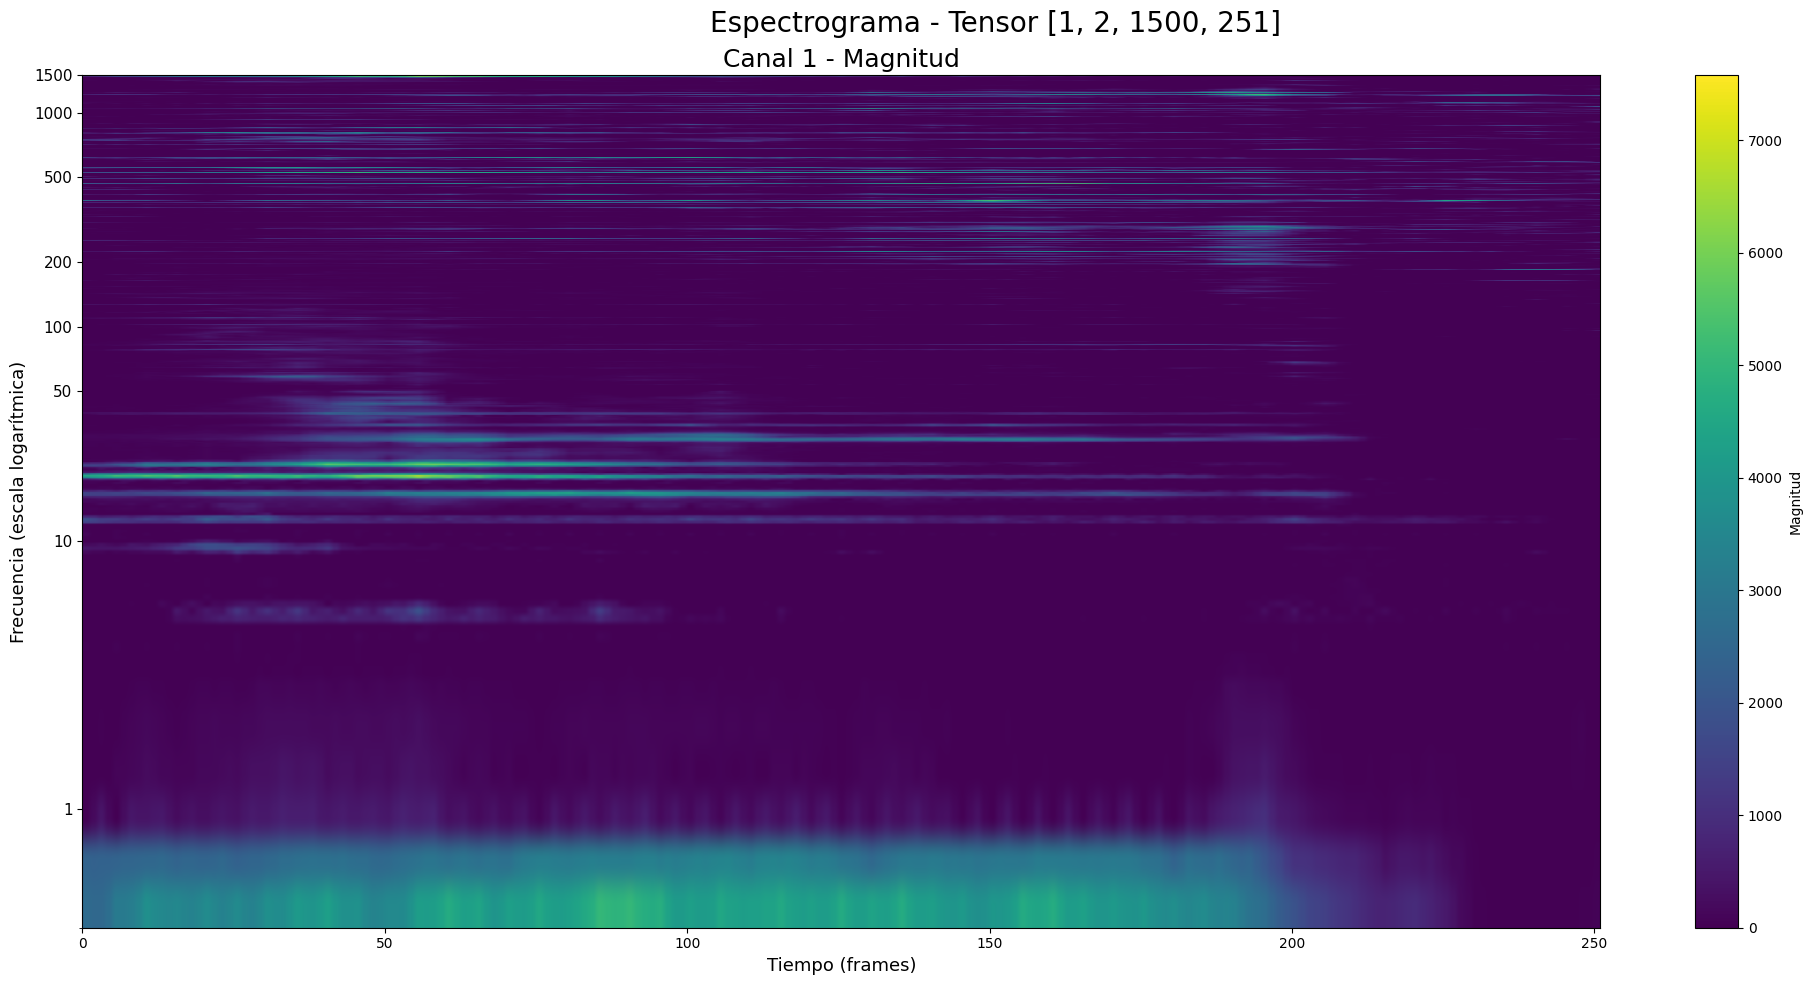

In [43]:
import soundfile as sf
import numpy as np

LATENT_DECODER = True
if LATENT_DECODER:
    latent_model, latent_scheduler = load_latent_model('encoder_latent')
    z = sample_latent(latent_model, latent_scheduler, latent_dim=200, num_samples=1, source='encoder_latent').to(device)
    del latent_model, latent_scheduler
    vae_model = load_encoder()
    with torch.no_grad():
        x = vae_model.decoder(z)
    print(z.shape)
    print(x.shape)
    display_tensor(x)
    # w = au.spectrogram_to_waveform(x)


In [53]:
import soundfile as sf
import numpy as np

LATENT_DECODER = True
if LATENT_DECODER:
    latent_model, latent_scheduler = load_latent_model('encoder_latent')
    waves = sample_audio(load_encoder(), latent_model, latent_scheduler, win_length= 4000, n_fft=4000, hop_length=300, num_samples=5)
    print(waves[0].shape)
    del latent_model, latent_scheduler
    display_audio(waves)

Encoder Loaded
(60000,)


In [59]:
# y, sr = librosa.load(r'C:\Users\Articuno\Desktop\TFG-info\data\example.wav')
import librosa
latent_model, latent_scheduler = load_latent_model('encoder_latent')
y, x = sample_audio_n_spect(load_encoder(), latent_model, latent_scheduler, win_length= 4000, n_fft=4000, hop_length=300)
sr = 16000
display_tensor(x)

# Plot the waveform using waveshow
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

# Compute STFT and plot
n_fft = 2048
hop_length = 512
ft = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))

def plot(data, title, sr, x_axis, y_axis, x_label, y_label, colorbar_label):
    plt.figure(figsize=(10, 4))  # Create a new figure for the STFT spectrogram
    librosa.display.specshow(data, sr=sr, x_axis=x_axis, y_axis=y_axis) #fmax=8000
    plt.colorbar(label=colorbar_label) # format='%+2.0f'
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

# 1. STFT Spectrogram (linear scale)
plot(ft, 'STFT Spectrogram (linear scale)', sr, 'time', 'linear', 'Time (s)', 'Frequency (Hz)', 'Amplitude')

# 2. STFT Spectrogram (log scale)
ft_dB = librosa.amplitude_to_db(ft, ref=np.max)
plot(ft_dB, 'STFT Spectrogram (log scale)', sr, 'time', 'linear', 'Time (s)', 'Frequency (Hz)', 'dB')

# 3. Mel Spectrogram (linear scale)
mel_sp = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
plot(mel_sp, 'Linear Mel Spectrogram', sr, 'time', 'mel', 'Time (s)', 'Mel frequency bins', 'Amplitude squared')

# 4. Mel Spectrogram (mel scale)
mel_sp_dB = librosa.power_to_db(mel_sp, ref=np.max)

plot(mel_sp_dB, 'Logarithmic Mel Spectrogram', sr, 'time', 'mel', 'Time (s)', 'Mel frequency bins', 'dB')




Encoder Loaded


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.